# Tarea 3 — Álgebra Lineal

Milton Beltrán - 20210030


## Helper de graficado


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def graficar(rests, xmax, ymax, verts=None, titulo=""):
    fig, ax = plt.subplots(figsize=(7, 6))
    x = np.linspace(0, xmax, 400)

    # malla de puntos: la region factible es donde todas las mascaras dan True
    X, Y = np.meshgrid(np.linspace(0, xmax, 500), np.linspace(0, ymax, 500))
    ok = np.ones_like(X, dtype=bool)
    for a, b, c, s in rests:
        ok &= (a * X + b * Y <= c) if s == "<=" else (a * X + b * Y >= c)
    ax.contourf(X, Y, ok.astype(int), levels=[0.5, 1.5],
                colors=["tab:blue"], alpha=0.25)

    for a, b, c, s in rests:
        et = f"{a}x + {b}y {s} {c}"
        if b == 0:
            ax.axvline(c / a, label=et)
        else:
            ax.plot(x, (c - a * x) / b, label=et)

    if verts:
        for px, py in verts:
            ax.plot(px, py, "ko")
            ax.annotate(f"({px:g}, {py:g})", (px, py),
                        textcoords="offset points", xytext=(6, 6))

    ax.set_xlim(0, xmax)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(titulo)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)
    plt.show()


---

## Serie 1: Conceptos


### Problema 1

**¿Qué es un sistema de desigualdades lineales y por qué su solución es una región y no un punto?**

Es un conjunto de dos o más desigualdades de primer grado en las mismas variables (por ejemplo $2x + y \le 800$, $x + y \le 500$), y su solución es una región y no un punto porque cada desigualdad no fija un valor sino que admite la intersección de eso semiplanos de puntos: un conjunto con infinitos puntos.

### Problema 2

**En un problema económico, ¿qué representan las condiciones de no-negatividad $x \ge 0$, $y \ge 0$?**

Representan que las variables miden cantidades reales del problema (unidades producidas, cuerdas sembradas, sacos comprados) que no pueden ser negativas, es decir que a lo sumo se puede no producir nada, y por eso restringen la región factible al primer cuadrante.


### Problema 3

**¿Por qué el óptimo de un problema de programación lineal acotado se encuentra siempre en un vértice de la región factible?**

Porque la función objetivo es lineal y sus curvas de nivel son rectas paralelas que tocan por última vez a esa región en un vértice, de modo que siempre existe un vértice donde se alcanza el óptimo.



### Problema 4

**¿Cómo se determina en cuál vértice de la región factible se encuentra la solución óptima de
un problema de programación lineal?**

Se hallan todos los vértices de la región factible resolviendo los sistemas $2 \times 2$ que forman las rectas que se cortan, se evalúa la función objetivo en cada vértice y se escoge el que dé el mayor valor si se maximiza o el menor si se minimiza.



---

## Serie 2: Desigualdades Lineales


### Problema 5

**Grafique la región de solución del siguiente sistema y encuentre todos sus vértices:**

$$R_1:\; 2x + y \le 800 \qquad R_2:\; x + y \le 500$$

$$R_3:\; x \ge 100 \qquad R_4:\; y \ge 50 \qquad x, y \ge 0$$


 El sistema ya viene dado. Límites: $2x + y = 800$, $x + y = 500$, $x = 100$, $y = 50$. Como $R_3$ y $R_4$ obligan a $x \ge 100$ y $y \ge 50$

**Vértices.** Se cortan los límites de dos en dos y se descarta lo que incumpla el sistema.

| Despeje | Punto | ¿Factible? |
|---|---|---|
| $x = 100,\; y = 50$ | $(100,\,50)$ | sí |
| $100 + y = 500$ | $(100,\,400)$ | sí |
| $2(100) + y = 800$ | $(100,\,600)$ | no: $100 + 600 > 500$ |
| $2x + 50 = 800$ | $(375,\,50)$ | sí |
| $x + 50 = 500$ | $(450,\,50)$ | no: $2(450) + 50 > 800$ |
| restando $R_2$ de $R_1$: $x = 300,\; y = 200$ | $(300,\,200)$ | sí |

**Vértices:** $(100,\,50)$, $(375,\,50)$, $(300,\,200)$, $(100,\,400)$. Región **acotada**.

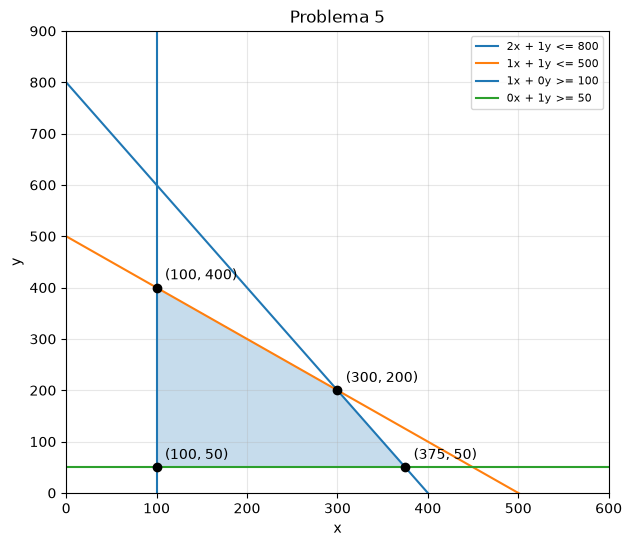

In [2]:
# Problema 5
rests = [(2, 1, 800, "<="), (1, 1, 500, "<="), (1, 0, 100, ">="), (0, 1, 50, ">=")]
verts = [(100, 50), (375, 50), (300, 200), (100, 400)]
graficar(rests, 600, 900, verts, "Problema 5")


### Problema 6

**Un productor siembra maíz ($x$, en cuerdas) y frijol ($y$, en cuerdas). Dispone de a lo sumo 40 cuerdas de terreno. Cada cuerda de maíz requiere 2 jornales y cada cuerda de frijol 1 jornal; cuenta con a lo sumo 60 jornales. Por contrato debe sembrar al menos 10 cuerdas de frijol.**

(a) Plantee el sistema de desigualdades.

(b) Grafique la región factible e identifique sus vértices.


**(a)** $x$ = cuerdas de maíz, $y$ = cuerdas de frijol.

$$
\begin{aligned}
R_1 \;(\text{terreno}):&\quad x + y \le 40\\
R_2 \;(\text{jornales}):&\quad 2x + y \le 60\\
R_3 \;(\text{contrato}):&\quad y \ge 10\\
&\quad x \ge 0,\; y \ge 0
\end{aligned}
$$

**(b) Vértices.**

| Despeje | Punto | ¿Factible? |
|---|---|---|
| $x = 0,\; y = 10$ | $(0,\,10)$ | sí |
| $0 + y = 40$ | $(0,\,40)$ | sí |
| $2(0) + y = 60$ | $(0,\,60)$ | no: $60 > 40$ |
| $x + 10 = 40$ | $(30,\,10)$ | no: $2(30) + 10 > 60$ |
| $2x + 10 = 60$ | $(25,\,10)$ | sí |
| restando $R_1$ de $R_2$: $x = 20,\; y = 20$ | $(20,\,20)$ | sí |

**Vértices:** $(0,\,10)$, $(25,\,10)$, $(20,\,20)$, $(0,\,40)$. Región **acotada**.

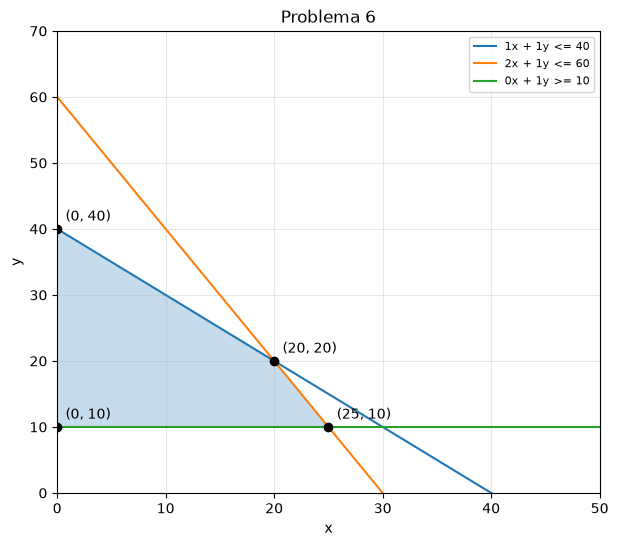

In [3]:
# Problema 6
rests = [(1, 1, 40, "<="), (2, 1, 60, "<="), (0, 1, 10, ">=")]
verts = [(0, 10), (25, 10), (20, 20), (0, 40)]
graficar(rests, 50, 70, verts, "Problema 6")


---

## Serie 3: Programación Lineal


### Problema 7

**Una cooperativa produjo durante esta cosecha 100 toneladas de café las cuales procesa en dos tipos de café: café con tueste blonde ($x$) y café con tueste oscuro ($y$), en quintales, con una ganancia de $Q30$ y $Q50$ por quintal, respectivamente. De primero, cada quintal de blonde se tuesta en 1 hora mientras que el oscuro se tuesta por 3 horas. Luego, el quintal de café blonde es más fino por lo que se muele por 2 horas mientras que el café oscuro es más grueso y sólo se muele por 1 hora. La cooperativa dispone de 240 horas para el proceso de tostado y de 180 horas para el proceso de molido.**

**Tipo de problema:** [ ] Maximización    [ ] Minimización

(a) Plantee el problema de programación lineal.

(b) Grafique la región factible y encuentre sus vértices.

(c) Evalúe la función objetivo en cada vértice y determine la producción que maximiza la ganancia.


**Tipo de problema: Maximización**

**(a)** $x$ = quintales de tueste blonde, $y$ = quintales de tueste oscuro.

$$
\begin{aligned}
\text{Max}\quad & Z = 30x + 50y\\[4pt]
R_1 \;(\text{tostado}):&\quad x + 3y \le 240\\
R_2 \;(\text{molido}):&\quad 2x + y \le 180\\
&\quad x \ge 0,\; y \ge 0
\end{aligned}
$$

Las 100 toneladas cosechadas ($\approx 2\,205$ qq) no restringen: con esas horas se procesan a lo sumo 90 qq.

**(b) Vértices.**

| Despeje | Punto | ¿Factible? |
|---|---|---|
| $x = 0,\; y = 0$ | $(0,\,0)$ | sí |
| $0 + 3y = 240$ | $(0,\,80)$ | sí |
| $2(0) + y = 180$ | $(0,\,180)$ | no: $3(180) > 240$ |
| $2x + 0 = 180$ | $(90,\,0)$ | sí |
| $x + 3(0) = 240$ | $(240,\,0)$ | no: $2(240) > 180$ |
| $y = 180 - 2x$ en $x + 3y = 240$: $-5x = -300$ | $(60,\,60)$ | sí |

**(c) Evaluación de $Z = 30x + 50y$:**

| Vértice | $Z$ |
|---|---|
| $(0,\,0)$ | $Q0$ |
| $(90,\,0)$ | $Q2\,700$ |
| $(60,\,60)$ | **$Q4\,800$** ← máximo |
| $(0,\,80)$ | $Q4\,000$ |

**Respuesta.** 60 qq de blonde y 60 qq de oscuro, con ganancia máxima de **$Q4\,800$**; ahí se agotan las 240 h de tostado y las 180 h de molido.

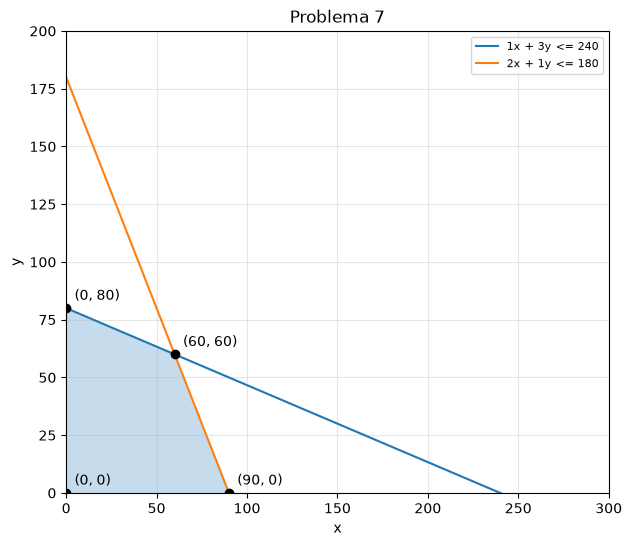

(0, 0) -> Z = 0
(90, 0) -> Z = 2700
(60, 60) -> Z = 4800
(0, 80) -> Z = 4000


In [4]:
# Problema 7
rests = [(1, 3, 240, "<="), (2, 1, 180, "<=")]
verts = [(0, 0), (90, 0), (60, 60), (0, 80)]
graficar(rests, 300, 200, verts, "Problema 7")

for x, y in verts:
    print(f"({x}, {y}) -> Z = {30 * x + 50 * y}")


### Problema 8

**Una finca prepara alimento mezclando dos concentrados $X$ ($Q4$ por saco) e $Y$ ($Q3$ por saco). La mezcla debe aportar al menos 12 gramos de proteína (1 por saco de $X$, 1 por saco de $Y$) y al menos 16 gramos de lípidos (2 por saco de $X$, 1 por saco de $Y$). Minimice el costo.**

(a) Plantee el problema de programación lineal.

(b) Grafique la región factible y encuentre sus vértices.

(c) Evalúe el costo en cada vértice y determine la mezcla de costo mínimo.


**(a)** $x$ = sacos del concentrado $X$, $y$ = sacos del concentrado $Y$.

$$
\begin{aligned}
\text{Min}\quad & C = 4x + 3y\\[4pt]
R_1 \;(\text{proteína}):&\quad x + y \ge 12\\
R_2 \;(\text{lípidos}):&\quad 2x + y \ge 16\\
&\quad x \ge 0,\; y \ge 0
\end{aligned}
$$

**(b) Vértices.**

| Despeje | Punto | ¿Factible? |
|---|---|---|
| $2(0) + y = 16$ | $(0,\,16)$ | sí |
| $0 + y = 12$ | $(0,\,12)$ | no: $12 < 16$ |
| $x + 0 = 12$ | $(12,\,0)$ | sí |
| $2x + 0 = 16$ | $(8,\,0)$ | no: $8 < 12$ |
| restando $R_1$ de $R_2$: $x = 4,\; y = 8$ | $(4,\,8)$ | sí |

Región **no acotada**, pero el mínimo existe: $C$ crece al alejarse del origen, así que el óptimo cae en uno de esos tres vértices.

**(c) Evaluación de $C = 4x + 3y$:**

| Vértice | $C$ |
|---|---|
| $(0,\,16)$ | $Q48$ |
| $(4,\,8)$ | **$Q40$** ← mínimo |
| $(12,\,0)$ | $Q48$ |

**Respuesta.** 4 sacos de $X$ y 8 de $Y$, con costo mínimo de **$Q40$**; ahí se cumplen justo los 12 g de proteína y los 16 g de lípidos.

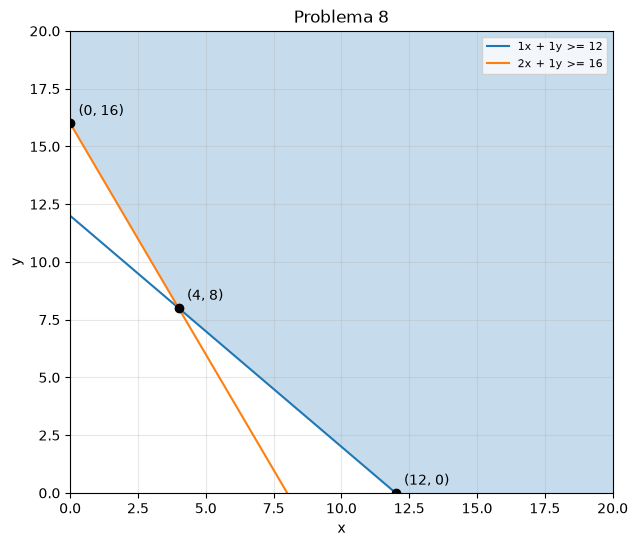

(0, 16) -> C = 48
(4, 8) -> C = 40
(12, 0) -> C = 48


In [5]:
# Problema 8
rests = [(1, 1, 12, ">="), (2, 1, 16, ">=")]
verts = [(0, 16), (4, 8), (12, 0)]
graficar(rests, 20, 20, verts, "Problema 8")

for x, y in verts:
    print(f"({x}, {y}) -> C = {4 * x + 3 * y}")
